In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.model_selection import GridSearchCV

In [2]:
data = pd.read_csv(r"C:\Users\Lenovo\Desktop\DEPI(R_2)\ML_git\GIZ4_AIS2_S1_Ml\src\ML\Session_7\Code\creditcard.csv")

In [3]:
data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
data = data.drop(["Time"] , axis=1)

Text(0.5, 1.0, 'Frequency of Classes')

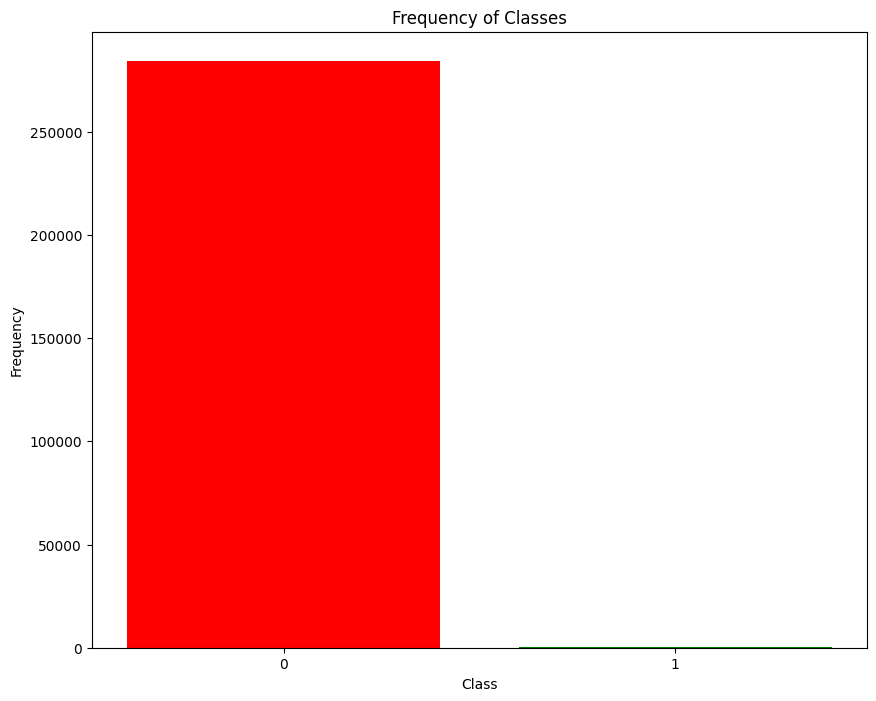

In [5]:
rcParams['figure.figsize'] = 10,8
plt.bar(data['Class'].unique(), data['Class'].value_counts(), color=['red', 'green'])
plt.xticks([0, 1])
plt.xlabel("Class")
plt.ylabel("Frequency")
plt.title("Frequency of Classes")

In [6]:
x = data.drop(['Class'], axis=1)
y = data['Class']

x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [7]:
hyper_param = {"criterion": ["entropy"],
                'max_depth':[4]}

dt_grid_param = GridSearchCV(estimator=DecisionTreeClassifier(),
                                param_grid=hyper_param,
                                scoring='roc_auc',
                                cv = 5)

dt_cv = dt_grid_param.fit(x_train,y_train)

print("the best parameters: " ,dt_cv.best_params_)
print("the best estimators: " ,dt_cv.best_estimator_)
print("the best score: " ,dt_cv.best_score_)


the best parameters:  {'criterion': 'entropy', 'max_depth': 4}
the best estimators:  DecisionTreeClassifier(criterion='entropy', max_depth=4)
the best score:  0.9395899317975902


# Bagging

In [8]:
hyper_param = {"n_estimators":[3,5,10]}

bagging_grid_param = GridSearchCV(estimator=BaggingClassifier(),
                                param_grid=hyper_param,
                                scoring='roc_auc',
                                cv = 5)

bagging_cv = bagging_grid_param.fit(x_train,y_train)

print("the best parameters: " ,bagging_cv.best_params_)
print("the best estimators: " ,bagging_cv.best_estimator_)
print("the best score: " ,bagging_cv.best_score_)


the best parameters:  {'n_estimators': 10}
the best estimators:  BaggingClassifier()
the best score:  0.9223573422264492


# RandomForest

In [10]:
hyper_param = {"criterion": ['entropy'],
                'max_depth':[4,10,20],
                'n_estimators': [5,10],
                'max_features':['sqrt']}

rf_grid_param = GridSearchCV(estimator= RandomForestClassifier(),
                                param_grid=hyper_param,
                                scoring='roc_auc',
                                cv = 5)

rf_cv = rf_grid_param.fit(x_train,y_train)

print("the best parameters: " ,rf_cv.best_params_)
print("the best estimators: " ,rf_cv.best_estimator_)
print("the best score: " ,rf_cv.best_score_)

the best parameters:  {'criterion': 'entropy', 'max_depth': 10, 'max_features': 'sqrt', 'n_estimators': 10}
the best estimators:  RandomForestClassifier(criterion='entropy', max_depth=10, n_estimators=10)
the best score:  0.9684286346041093


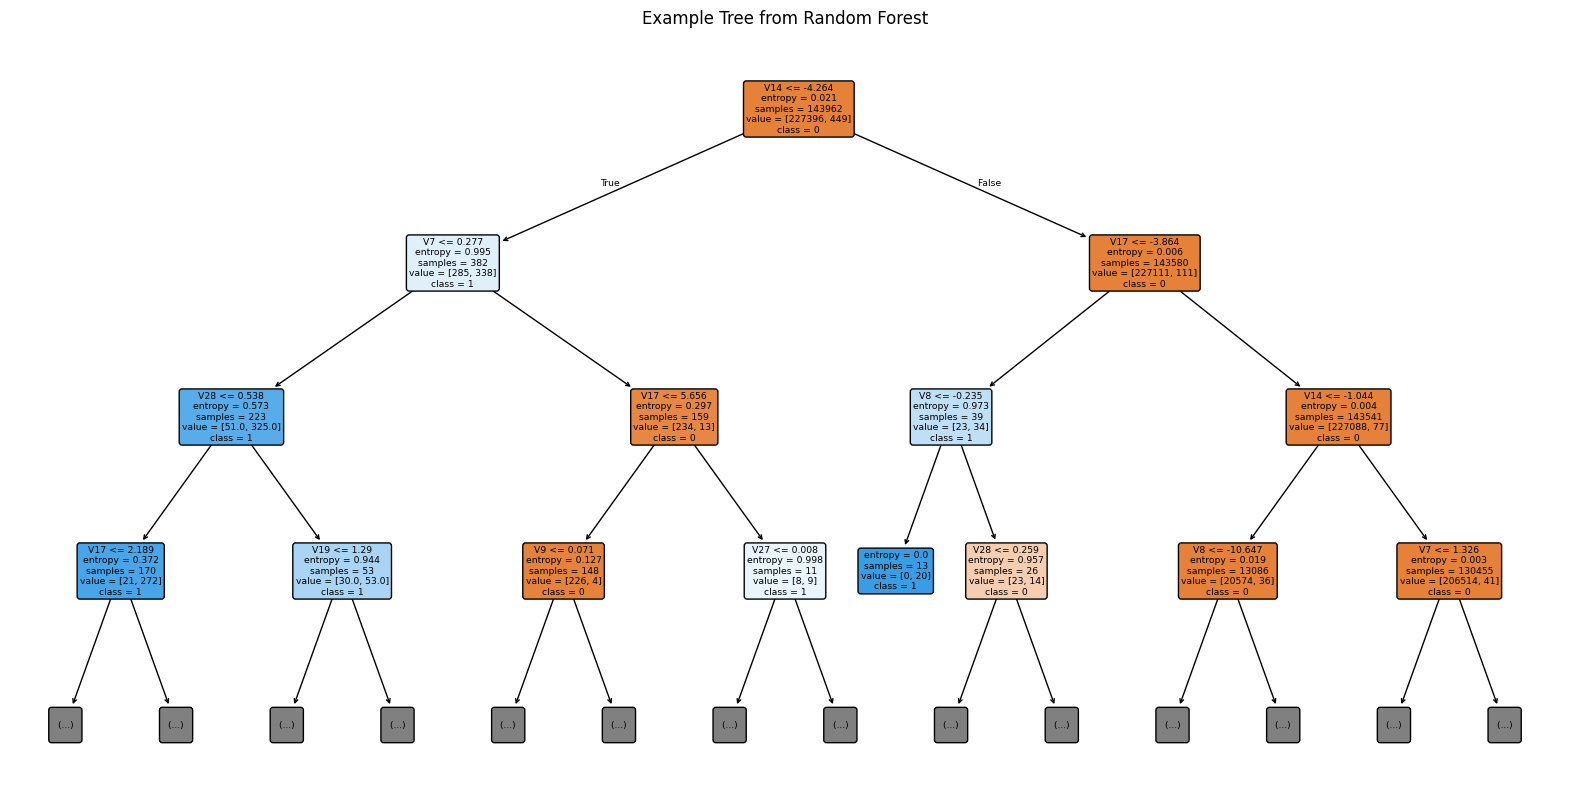

In [ ]:
from sklearn import tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))

tree.plot_tree(
    rf_cv.best_estimator_[0],
    feature_names=x_train.columns,
    class_names=['0','1'],   # because your class is encoded as 0 and 1
    filled=True,
    rounded=True,
    max_depth=3   # optional to keep the plot readable
)

plt.title("Example Tree from Random Forest")
plt.show()